In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import itertools
from PIL import Image
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation  , Dropout , BatchNormalization

from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_data='/kaggle/input/brain-tumor-mri-dataset/Training'
filepaths=[]
labels=[]

folds=os.listdir(train_data)

for fold in folds:
    foldpath=os.path.join(train_data,fold)
    filelist=os.listdir(foldpath)
    
    for fpath in filelist:
        fillpath=os.path.join(foldpath,fpath)
        
        labels.append(fold)
        filepaths.append(fillpath)
        
file_series=pd.Series(filepaths,name='filepaths')
label_series=pd.Series(labels,name='labels')
train_df=pd.concat([file_series,label_series],axis=1)

In [3]:
train_df

,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5595,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5596,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5597,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5598,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [4]:
test_data='/kaggle/input/brain-tumor-mri-dataset/Testing'
filepaths=[]
labels=[]

folds=os.listdir(test_data)

for fold in folds:
    foldpath=os.path.join(test_data,fold)
    filelist=os.listdir(foldpath)
    
    for fpath in filelist:
        fillpath=os.path.join(foldpath,fpath)
        
        labels.append(fold)
        filepaths.append(fillpath)
        
file_series=pd.Series(filepaths,name='filepaths')
label_series=pd.Series(labels,name='labels')
ts_df=pd.concat([file_series,label_series],axis=1)

In [5]:
ts_df

,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1595,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1596,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1597,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1598,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


In [6]:
val_df, test_df= train_test_split(ts_df,test_size=0.5,random_state= 43)

In [7]:
val_df

,filepaths,labels
1347,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1337,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
744,/kaggle/input/brain-tumor-mri-dataset/Testing/...,notumor
1301,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
943,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
...,...,...
16,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
58,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
277,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
255,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary


In [8]:
batch_size = 16
image_size = (224, 224)

train_genrator = ImageDataGenerator()
test_genrator = ImageDataGenerator()


train_genrator = train_genrator.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', 
                                                    target_size= image_size, 
                                                    class_mode= 'categorical',
                                    
                                                    color_mode= 'rgb', 
                                                    shuffle= True, 
                                                    batch_size= batch_size)

valid_genrator = test_genrator.flow_from_dataframe( val_df, x_col= 'filepaths', 
                                                   y_col= 'labels', 
                                                   target_size= image_size, 
                                                   class_mode= 'categorical',
                                    
                                                   color_mode= 'rgb', 
                                                   shuffle= True, 
                                                   batch_size= batch_size)

test_genrator = test_genrator.flow_from_dataframe( test_df, x_col= 'filepaths', 
                                                  y_col= 'labels', 
                                                  target_size= image_size, 
                                                  class_mode= 'categorical',
                                    
                                                  color_mode= 'rgb', 
                                                  shuffle= False, 
                                                  batch_size= batch_size)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [9]:
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

class_count = len(list(train_genrator.class_indices.keys())) # to define number of classes in dense layer

model = Sequential([
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu", input_shape= img_shape),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)), 
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(256,activation = "relu"),
    Dense(64,activation = "relu"),
    Dense(class_count, activation = "softmax")
])
model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,154,180 (80.70 MB)

 Trainable params: 21,154,180 (80.70 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(train_genrator, 
                    epochs= 10, 
                    verbose= 1, 
                    validation_data= valid_genrator, 
                    shuffle= False)

Epoch 1/10


I0000 00:00:1773941280.438663     108 service.cc:145] XLA service 0x7be3dc0033b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773941280.438721     108 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773941280.438725     108 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773941304.298285     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


350/350 ━━━━━━━━━━━━━━━━━━━━ 108s 232ms/step - accuracy: 0.4290 - loss: 6.8604 - val_accuracy: 0.6475 - val_loss: 0.8668
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 254ms/step - accuracy: 0.7614 - loss: 0.5957 - val_accuracy: 0.7975 - val_loss: 1.0303
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 88s 253ms/step - accuracy: 0.8649 - loss: 0.3747 - val_accuracy: 0.7900 - val_loss: 0.7852
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 254ms/step - accuracy: 0.8903 - loss: 0.3168 - val_accuracy: 0.8388 - val_loss: 0.7700
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 254ms/step - accuracy: 0.9113 - loss: 0.2212 - val_accuracy: 0.8637 - val_loss: 0.6233
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 254ms/step - accuracy: 0.9250 - loss: 0.1859 - val_accuracy: 0.8525 - val_loss: 0.6785
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 254ms/step - accuracy: 0.9525 - loss: 0.1411 - val_accuracy: 0.8800 - val_loss: 0.6024
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 254ms/step - accuracy: 0.9623 - loss: 0.1129 - va

In [11]:
# Evaluate
train_loss, train_acc = model.evaluate(train_genrator, verbose=1)
valid_loss, valid_acc = model.evaluate(valid_genrator, verbose=1)
test_loss, test_acc = model.evaluate(test_genrator, verbose=1)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {valid_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

350/350 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9813 - loss: 0.0497
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8786 - loss: 1.0720
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.8830 - loss: 0.9691

Train Accuracy: 0.9814
Validation Accuracy: 0.8712
Test Accuracy: 0.8763


In [12]:
# Predictions
y_pred_probs = model.predict(test_genrator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_genrator.classes

# Class names
class_names = list(test_genrator.class_indices.keys())

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step


In [13]:
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

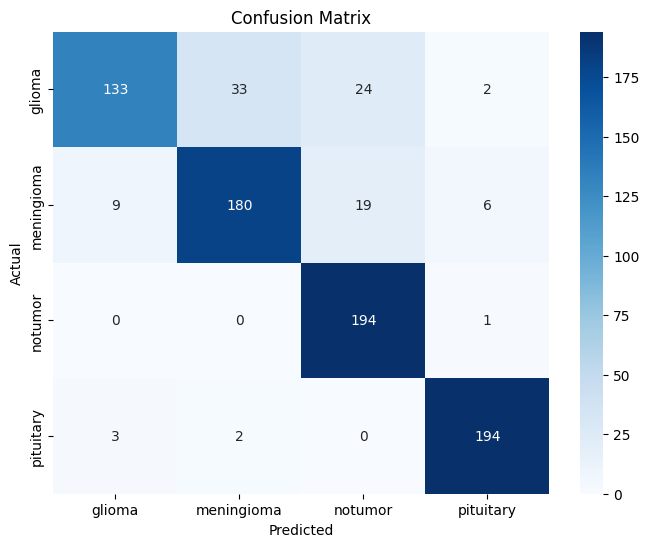

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

      glioma       0.92      0.69      0.79       192
  meningioma       0.84      0.84      0.84       214
     notumor       0.82      0.99      0.90       195
   pituitary       0.96      0.97      0.97       199

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.87       800
weighted avg       0.88      0.88      0.87       800



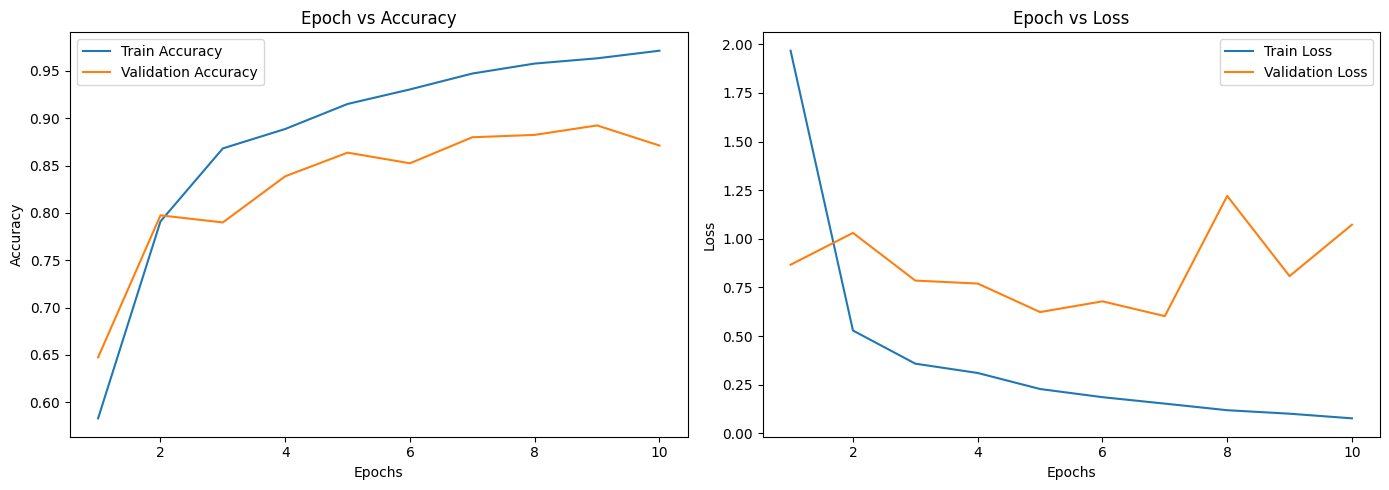

In [16]:
# Extract history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(14,5))

# 🔹 Accuracy Plot
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Epoch vs Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 🔹 Loss Plot
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Epoch vs Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
model.save("brain_tumor_model.h5")